# Object Tracking Demo: „Welche Objekte bewegen sich über die Zeit?“

Bisher haben wir Objekterkennung **pro Bild / pro Frame** gemacht.
Dabei gilt:
- Jede Erkennung ist unabhängig
- Es gibt **keine stabilen Objekt-IDs über Frames hinweg**

**Object Tracking** behandelt nun genau dieses Problem: es weist Objekten statische 
**IDs** zu und verfolgt diese dann über mehrere Frames.

In dieser Demo schauen wir uns drei Varianten von Objekt Tracking Methoden an:
1) YOLO-internes Tracking (sehr einfach)
2) ByteTrack (motion-basiert)
3) DeepSORT (motion- + appearance-basiert)

Wichtig: ab jetzt arbeiten wir nur noch mit **Videos**.

In [ ]:
# nötige Packages..
!pip -q install ultralytics opencv-python matplotlib numpy deep_sort_realtime

## Testvideo laden und genauer ansehen...

Mit dem `cv2` (opencv-python) package lassen sich auch Videos gut verarbeiten - hier
sehen wir uns nun zunächst das erste Frame im speziellen, und dann das ganze Video an.

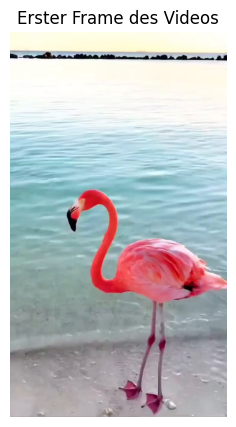

Videoformat: (1280, 720, 3)


In [19]:
import cv2
import matplotlib.pyplot as plt

video_path = "/home/u88m52/projects/DIH-CV/videos/flamingo.mp4"
cap = cv2.VideoCapture(video_path)

ret, frame_bgr = cap.read()
frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(7,5))
plt.imshow(frame_rgb)
plt.axis("off")
plt.title("Erster Frame des Videos")
plt.show()

print("Videoformat:", frame_rgb.shape)  # Höhe, Breite, Kanäle

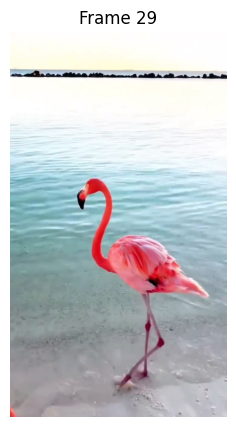

In [25]:
from IPython.display import display, clear_output
import time

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise ValueError(f"Cannot open video {video_path}")

fig, ax = plt.subplots(figsize=(8, 5))

for i in range(30):
    ret, frame = cap.read()
    if not ret:
        break

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
    ax.clear()  # clear previous frame
    ax.imshow(frame_rgb)
    ax.axis('off')
    ax.set_title(f"Frame {i}")
    
    clear_output(wait=True)
    display(fig)
    time.sleep(0.01)

cap.release()
plt.close(fig)

## Ein Modell laden

Wir benutzen wieder ein YOLO-Modell, der einfachheit halber ein Detektionsmodell:

In [21]:
from ultralytics import YOLO

det_model = YOLO("yolo11s.pt")
det_model

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(96, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(128, eps=0.001, momentum=0.03, affine=True, track_runnin

Das Detection-Modell ist geladen.

Als nächstes bauen wir die ByteTrack-Pipeline:
- pro Frame: YOLO Detection
- dann: Detections in ByteTrack-Format umwandeln
- dann: ByteTrack `update()` → Tracks mit IDs

Wichtig: In manchen Ultralytics-Versionen benötigt `BYTETracker` ein `args`-Objekt.
Das geben wir explizit an (inkl. `frame_rate`, passend zur effektiven FPS).

In [33]:
from ultralytics.trackers.byte_tracker import BYTETracker
from ultralytics.utils import IterableSimpleNamespace

bt_args = IterableSimpleNamespace(
    track_high_thresh=0.5,
    track_low_thresh=0.1,
    new_track_thresh=0.6,
    track_buffer=30,
    match_thresh=0.8,
    frame_rate=5,
    mot20=False
)

bt_tracker = BYTETracker(bt_args)
print("ByteTrack init OK")


ByteTrack init OK


In [ ]:
import os

out_path_bt = "tracking_bytetrack_5fps.mp4"
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = None

cap = cv2.VideoCapture(video_path)
assert cap.isOpened()

conf_thres = 0.25   # für kleine/unsichere Objekte ggf. 0.10
imgsz = 640         # ggf. 960 für bessere Detection (langsamer)

frame_idx = 0
written = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Frame skipping => ~5 FPS processing
    if frame_idx % stride != 0:
        frame_idx += 1
        continue

    if writer is None:
        writer = cv2.VideoWriter(out_path_bt, fourcc, eff_fps, (frame.shape[1], frame.shape[0]))

    # --- YOLO Detection ---
    det = det_model.predict(frame, conf=conf_thres, imgsz=imgsz, verbose=False)[0]
    boxes = det.boxes

    if boxes is None or len(boxes) == 0:
        writer.write(frame)
        frame_idx += 1
        written += 1
        continue

    # ByteTrack erwartet: [x1,y1,x2,y2,score,cls]
    dets = np.concatenate([
        boxes.xyxy.cpu().numpy(),
        boxes.conf.cpu().numpy()[:, None],
        boxes.cls.cpu().numpy()[:, None]
    ], axis=1).astype(np.float32)

    tracks = bt_tracker.update(dets, frame)  # -> typ. [x1,y1,x2,y2,track_id,cls]

    # --- Draw ---
    for t in tracks:
        x1, y1, x2, y2, tid, cls = t
        x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])
        tid = int(tid)
        cls = int(cls)
        label = f"ID {tid} | {det.names.get(cls, cls)}"

        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(frame, label, (x1, max(0, y1-6)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    writer.write(frame)
    frame_idx += 1
    written += 1

cap.release()
if writer is not None:
    writer.release()

print("Wrote:", out_path_bt, "| frames written:", written)